# ParaSpeechCaps

In [ ]:
import json
import pandas as pd


with open("C:/Users/jackm/Documents/GitHub/ms-capstone-TTS-natlang-styleprompts/src/data/raw/paraspeechcaps/audio/EARS/speaker_statistics.json", "r") as f:
    data = json.load(f)

# keys -> index, then move index into a column
df = pd.DataFrame.from_dict(data, orient="index").reset_index()

# rename the index column
psc_df = df.rename(columns={"index": "speaker_id"})

df

Show distributions of stats in EARS:

In [ ]:
import matplotlib.pyplot as plt

stat_columns = [c for c in df.columns if c != "speaker_id"]

for col in stat_columns:
    plt.figure()
    ax = psc_df[col].value_counts().sort_index().plot(kind="bar")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")

    # add numbers on top of bars
    for p in ax.patches:
        ax.annotate(
            str(int(p.get_height())),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


To get a more balanced speaker set, we want to reduce some speakers of the majority classes (white/caucasian, american english).
This information will help us choose which files to not download from EARS.
Hopefully this allows the model to generalize more.

In [18]:
criteria = {
    "ethnicity": "white or caucasian",
    "native language" : "american english"
}

n = 20  # number of rows to pick

# Step 1: create mask for rows matching all criteria
mask = (df[list(criteria)] == pd.Series(criteria)).all(axis=1)

# Step 2: get the matching rows
matching = df[mask]

# Step 3: sample n rows from matches (safe if fewer than n exist)
selected = matching.sample(n=min(n, len(matching)), random_state=42)

# Step 4: remove selected rows from original dataframe
df_balanced = df.drop(selected.index)

df_balanced

,speaker_id,age,ethnicity,gender,weight,native language,height
0,p001,36-45,white or caucasian,male,160 - 180 lbs,german,6' - 6'3
2,p003,26-35,black or african american,female,100 - 120 lbs,american english,5'4 - 5'7
3,p004,18-25,white or caucasian,male,140 - 160 lbs,american english,5'8 - 5'11
4,p005,18-25,asian,male,140 - 160 lbs,mandarin,5'4 - 5'7
5,p006,36-45,hispanic or latino,female,200 - 220 lbs,american english,< 5'
...,...,...,...,...,...,...,...
102,p103,prefer not to answer,prefer not to answer,prefer not to answer,prefer not to answer,prefer not to answer,prefer not to answer
103,p104,56-65,white or caucasian,female,180 - 200 lbs,american english,5'4 - 5'7
104,p105,36-45,black or african american,male,220 - 240 lbs,american english,6' - 6'3
105,p106,56-65,white or caucasian,female,120 - 140 lbs,american english,5' - 5'3


new distributions:

In [ ]:
import matplotlib.pyplot as plt

stat_columns = [c for c in df_balanced.columns if c != "speaker_id"]

for col in stat_columns:
    plt.figure()
    ax = df_balanced[col].value_counts().sort_index().plot(kind="bar")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")

    # add numbers on top of bars
    for p in ax.patches:
        ax.annotate(
            str(int(p.get_height())),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

In [ ]:
# get speaker ids to EXCLUDE
list(selected["speaker_id"])

## PSC Annotations

### Raw

In [ ]:
from datasets import load_dataset
import pandas as pd

# train_scaled = load_dataset("ajd12342/paraspeechcaps", split="train_scaled") #Only has EMilia files
train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base") 
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

psc_dfs = [
    train_base.to_pandas(),
    holdout.to_pandas(),
    dev.to_pandas(),
    test.to_pandas()
    # ,train_scaled.to_pandas()
]

# merge into one dataframe
psc_df = pd.concat(psc_dfs, ignore_index=True)

# filter out VoxCeleb, Emilia
psc_df = psc_df[psc_df["source"] == "voxceleb"]

### Processed

In [5]:
import pandas as pd
df = pd.read_parquet("../data/processed/merged_PSC_StyleTalk_CLEANED.parquet")
psc_df = df[df["source"] == "expresso"]
st_df = df[df["source"] == "styletalk"]

In [ ]:
# basic eda for expresso
import matplotlib.pyplot as plt


categorical_cols = [
    "gender",
    "accent",
    "speaking_rate",
    "noise",
]

noise_labels = [
    "very clean environment",
    "clean environment",
    "slightly clean environment",
    "environment balanced in clarity",
    "slightly noisy environment",
    "noisy environment",
    "very noisy environment"
]

speaking_rate_labels = [
    "slow speed", "measured speed", "fast speed"
]

order_map = {
    "noise": noise_labels,
    "pitch": pitch_labels,
    "speaking_rate": speaking_rate_labels,
}

for col in categorical_cols:
    expresso_counts = expresso_df[col].value_counts(dropna=False)
    ears_counts = ears_df[col].value_counts(dropna=False)
    
    if col in order_map:
        idx = order_map[col]
    else:
        idx = expresso_counts.index.union(ears_counts.index)
    
    expresso_counts = expresso_counts.reindex(idx, fill_value=0)
    ears_counts = ears_counts.reindex(idx, fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    expresso_counts.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Expresso")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("count")
    axes[0].tick_params(axis="x", rotation=45)

    ears_counts.plot(kind="bar", ax=axes[1])
    axes[1].set_title("EARS")
    axes[1].set_xlabel(col)
    axes[1].tick_params(axis="x", rotation=45)
    
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    fig.suptitle(f"{col} distribution")

    plt.tight_layout()
    plt.savefig(f"figures/psc_{col}_frequency.png", dpi=300, bbox_inches="tight")
    plt.close()

In [9]:
# Special plot for pitch (gender separated)
import matplotlib.pyplot as plt
import numpy as np

idx = [
    "low-pitched", "medium-pitched", "high-pitched"
]

def pitch_gender_counts(df):
    # table: pitch x gender
    ct = (
        df.groupby(["pitch", "gender"])
        .size()
        .unstack(fill_value=0)
    )

    # ensure all bins exist
    ct = ct.reindex(idx, fill_value=0)

    # ensure both genders exist
    for g in ["male", "female"]:
        if g not in ct.columns:
            ct[g] = 0

    return ct[["male", "female"]]

expresso_ct = pitch_gender_counts(expresso_df)
ears_ct = pitch_gender_counts(ears_df)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

width = 0.35
x = np.arange(len(idx))

# --- Expresso
axes[0].bar(x - width/2, expresso_ct["male"], width, label="male")
axes[0].bar(x + width/2, expresso_ct["female"], width, label="female")
axes[0].set_title("Expresso")
axes[0].set_xticks(x)
axes[0].set_xticklabels(idx, rotation=45, ha="right", rotation_mode="anchor")
axes[0].set_ylabel("count")
axes[0].legend()

# --- EARS
axes[1].bar(x - width/2, ears_ct["male"], width, label="male")
axes[1].bar(x + width/2, ears_ct["female"], width, label="female")
axes[1].set_title("EARS")
axes[1].set_xticks(x)
axes[1].set_xticklabels(idx, rotation=45, ha="right", rotation_mode="anchor")
axes[1].legend()

fig.suptitle("Pitch distribution by gender")

plt.tight_layout()
plt.savefig("figures/psc_pitch_gender_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

In [12]:
# Continuous basic ed

# duration histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Expresso
vals = expresso_df["duration"].dropna()
weights = np.ones(len(vals)) / len(vals) * 100
axes[0].hist(vals, bins=50, weights=weights)
axes[0].set_title("Expresso")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("percent")

# EARS
vals = ears_df["duration"].dropna()
weights = np.ones(len(vals)) / len(vals) * 100
axes[1].hist(vals, bins=50, weights=weights)
axes[1].set_title("EARS")
axes[1].set_xlabel("seconds")

fig.suptitle("Duration histogram")

plt.tight_layout()
plt.savefig("figures/psc_duration_hist_percent.png", dpi=300)
plt.close()


# snr v duration scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(expresso_df["duration"], expresso_df["snr"], alpha=0.3)
axes[0].set_title("Expresso")
axes[0].set_xlabel("duration (s)")
axes[0].set_ylabel("snr (dB)")

axes[1].scatter(ears_df["duration"], ears_df["snr"], alpha=0.3)
axes[1].set_title("EARS")
axes[1].set_xlabel("duration (s)")

fig.suptitle("SNR vs duration")

plt.tight_layout()
plt.savefig("figures/psc_snr_duration_scatter.png", dpi=300)
plt.close()


# pitch distribution by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

bins = 40


def plot_pitch(ax, df, title):
    male = df[df["gender"] == "male"]["utterance_pitch_mean"].dropna()
    female = df[df["gender"] == "female"]["utterance_pitch_mean"].dropna()

    if len(male) > 0:
        weights = np.ones(len(male)) / len(male) * 100
        ax.hist(male, bins=bins, weights=weights, alpha=0.5, label="male")

    if len(female) > 0:
        weights = np.ones(len(female)) / len(female) * 100
        ax.hist(female, bins=bins, weights=weights, alpha=0.5, label="female")

    ax.set_title(title)
    ax.set_xlabel("Hz")
    ax.set_ylabel("percent")
    ax.legend()


plot_pitch(axes[0], expresso_df, "Expresso")
plot_pitch(axes[1], ears_df, "EARS")

fig.suptitle("Pitch distribution by gender (%)")

plt.tight_layout()
plt.savefig("figures/psc_pitch_gender_hist_percent.png", dpi=300)
plt.close()

In [6]:
# Plot tag distribution

intrinsic_counts = (
    psc_df['intrinsic_tags']
    .explode()
    .value_counts()
    .reset_index()
)
situation_counts = (
    psc_df['situational_tags']
    .explode()
    .value_counts()
    .reset_index()
)

st_counts = (
    st_df['all_tags']
    .explode()
    .value_counts()
    .reset_index()
)


intrinsic_counts.columns = ['tag', 'count']
situation_counts.columns = ['tag', 'count']
st_counts.columns = ['tag', 'count']


# print(situation_counts.head())
# print(intrinsic_counts.head())

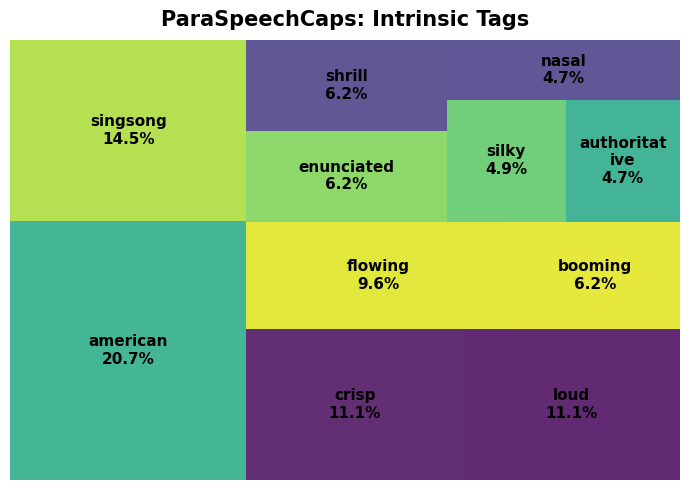

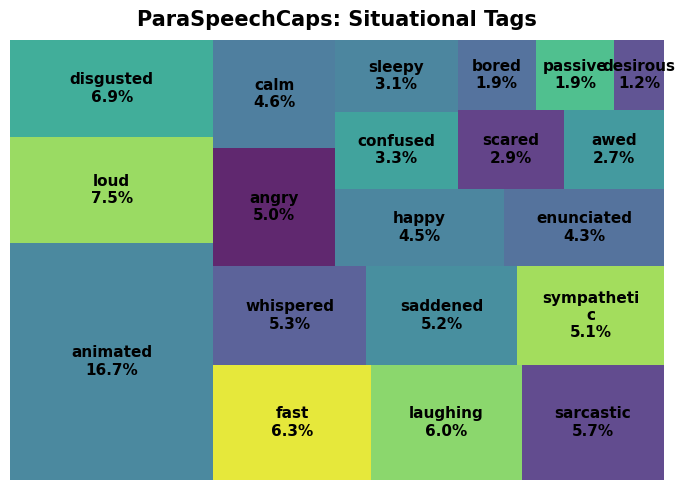

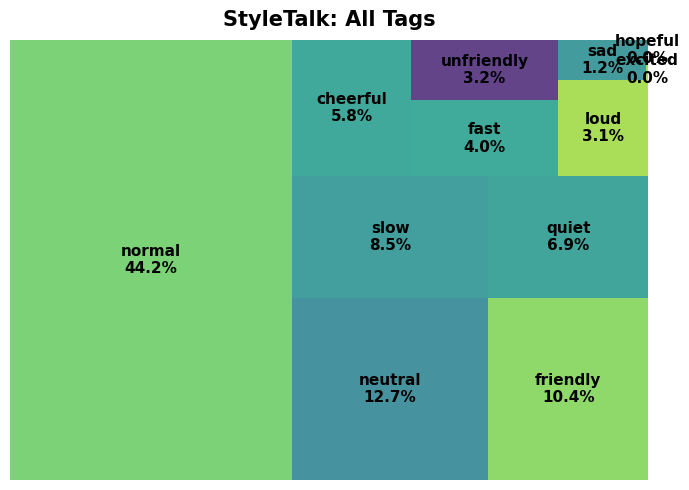

In [13]:
# treemaps
import matplotlib.pyplot as plt
import squarify
import textwrap
import os

os.makedirs('figures', exist_ok=True)


def plot_treemap(sizes, labels, title, filename, figsize=(7,5)):
    sizes = list(sizes)
    labels = list(labels)
    total = sum(sizes)
    # Wrap long labels and append counts
    wrapped_labels = [
        f"{textwrap.fill(str(l), width=10)}\n{100*c/total:.1f}%"
        for l, c in zip(labels, sizes)
    ]

    fig, ax = plt.subplots(figsize=figsize)

    squarify.plot(
        sizes=sizes,
        label=wrapped_labels,
        alpha=0.85,
        ax=ax,
        text_kwargs={
            'fontsize': 11,
            'fontweight': 'bold',
            'wrap': True,
        }
    )

    ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig(f"figures/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


plot_treemap(intrinsic_counts['count'],  intrinsic_counts['tag'], 'ParaSpeechCaps: Intrinsic Tags',   'psc_intrinsic_tag_treemap.png')

plot_treemap(situation_counts['count'],  situation_counts['tag'],'ParaSpeechCaps: Situational Tags', 'psc_situational_tag_treemap.png')

plot_treemap(st_counts['count'], st_counts['tag'],'StyleTalk: All Tags','styletalk_tag_treemap.png')

Processing rows: 100%|██████████| 22784/22784 [00:00<00:00, 173169.42it/s]


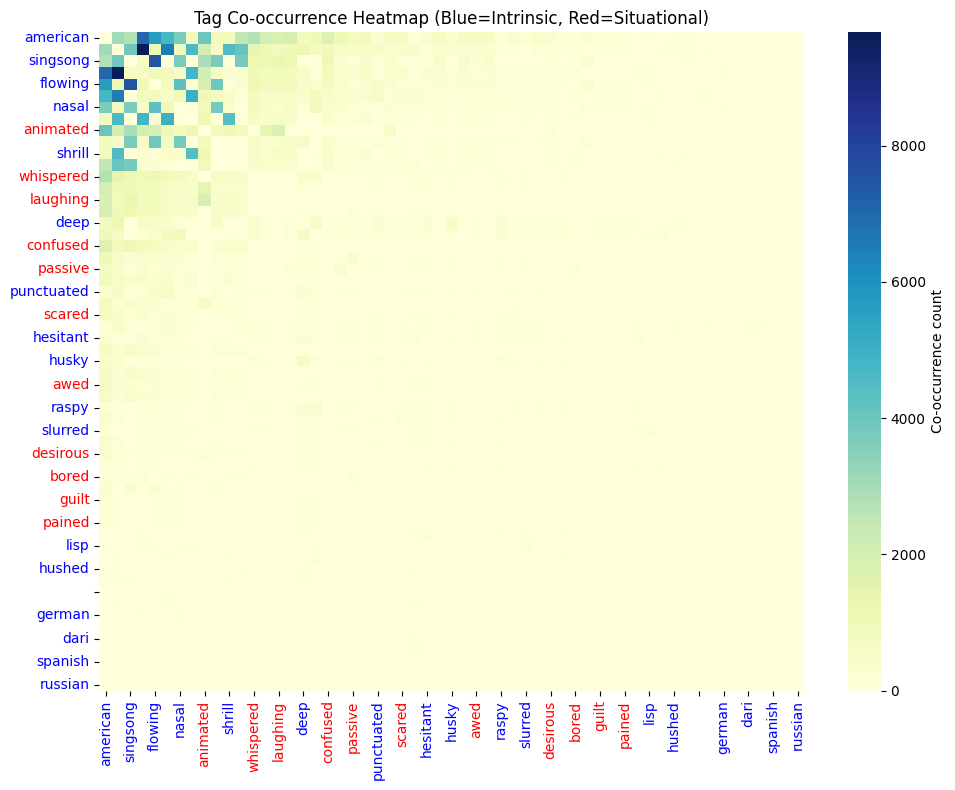

In [29]:
# Co-occurence heatmap
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm import tqdm

psc_df = psc_df[psc_df['situational_tags'].notna()]
psc_df = psc_df[psc_df['intrinsic_tags'].notna()]
# Step 1: Get all unique tags and their types
intrinsic_tags = set(tag for tags in psc_df['intrinsic_tags'] for tag in tags)
situational_tags = set(tag for tags in psc_df['situational_tags'] for tag in tags)

all_tags = list(intrinsic_tags | situational_tags)
tag_types = {tag: 'intrinsic' if tag in intrinsic_tags else 'situational' for tag in all_tags}

# Step 2: Build co-occurrence matrix
co_matrix = pd.DataFrame(0, index=all_tags, columns=all_tags)
all_pairs = []
for intrinsic, situational in tqdm(zip(psc_df['intrinsic_tags'], psc_df['situational_tags']),
                                    total=len(psc_df), desc="Processing rows"):
    combined_tags = list(intrinsic) + list(situational)  # safe conversion
    if len(combined_tags) < 2:
        continue  # skip rows with <2 tags
    all_pairs.extend(combinations(combined_tags, 2))

# Step 4: Count occurrences of each pair
from collections import Counter

pair_counts = Counter(all_pairs)

# Step 5: Fill the co-occurrence matrix
for (t1, t2), count in pair_counts.items():
    co_matrix.loc[t1, t2] = count
    co_matrix.loc[t2, t1] = count  # symmetric
    
# Remove rows where all values are 0
co_matrix = co_matrix.loc[~(co_matrix==0).all(axis=1), :]

# Remove columns where all values are 0
co_matrix = co_matrix.loc[:, ~(co_matrix==0).all(axis=0)]

# Compute total co-occurrence per tag
tag_totals = co_matrix.sum(axis=1)

# Sort tags by descending total count
sorted_tags = tag_totals.sort_values(ascending=False).index

# Reorder matrix
co_matrix_sorted = co_matrix.loc[sorted_tags, sorted_tags]
# Step 3: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_sorted, annot=False, fmt="d", cmap='YlGnBu', cbar_kws={'label': 'Co-occurrence count'})


# Step 4: Color the tick labels
ax = plt.gca()

# X-axis
for label in ax.get_xticklabels():
    tag = label.get_text()
    if tag_types[tag] == 'intrinsic':
        label.set_color('blue')
    else:
        label.set_color('red')

# Y-axis
for label in ax.get_yticklabels():
    tag = label.get_text()
    if tag_types[tag] == 'intrinsic':
        label.set_color('blue')
    else:
        label.set_color('red')

plt.title("Tag Co-occurrence Heatmap (Blue=Intrinsic, Red=Situational)")
plt.tight_layout()
plt.show()


In [ ]:
# tSNE plot for situational tag occurence 
from sklearn.manifold import TSNE

psc_df_nona = psc_df[psc_df['situational_tags'].notna()]
tags = psc_df_nona['situational_tags'].explode().unique()

# Build tag-situation matrix
all_tags = list(tags)
matrix = np.zeros((len(psc_df_nona), len(all_tags)))

for i, tag_list in enumerate(psc_df_nona['situational_tags']):

    for t in tag_list:
        matrix[i, all_tags.index(t)] = 1

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(matrix)  # transpose to get tag vectors

plt.figure(figsize=(10,8))
for i, t in enumerate(all_tags):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.05, y+0.05, t)
plt.title("t-SNE projection of tag co-occurrence")
plt.show()

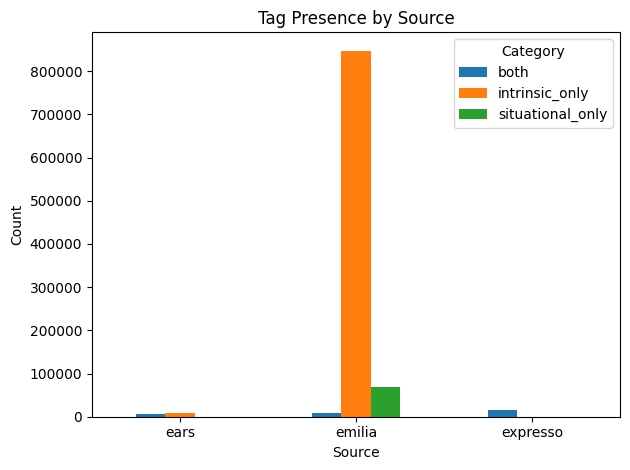

In [4]:
# tag type distribution
import pandas as pd
import numpy as np

def is_populated(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    if isinstance(x, str):
        return x != 'None' and x.strip() != ''
    if isinstance(x, (list, tuple, np.ndarray)):
        return len(x) > 0
    return True  # fallback for other types

psc_df['has_intrinsic'] = psc_df['intrinsic_tags'].apply(is_populated)
psc_df['has_situational'] = psc_df['situational_tags'].apply(is_populated)

def categorize(row):
    if row['has_intrinsic'] and row['has_situational']:
        return 'both'
    elif row['has_intrinsic']:
        return 'intrinsic_only'
    elif row['has_situational']:
        return 'situational_only'
    else:
        return 'neither'

psc_df['tag_category'] = psc_df.apply(categorize, axis=1)

counts = (
    psc_df.groupby(['source', 'tag_category'])
      .size()
      .unstack(fill_value=0)
)

import matplotlib.pyplot as plt

counts.plot(kind='bar')

plt.title('Tag Presence by Source')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()

plt.show()

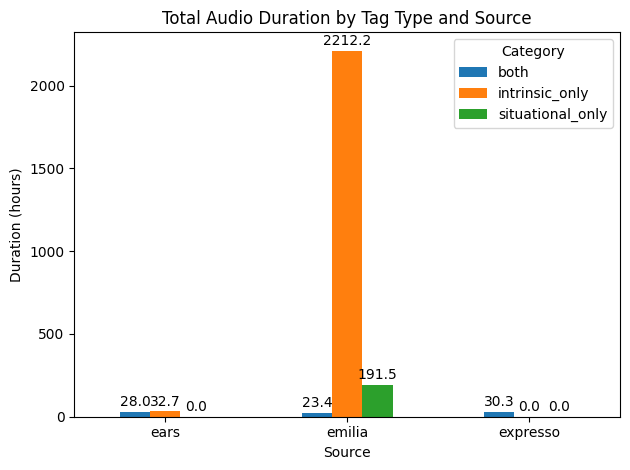

In [11]:
# duration for each tag type
import pandas as pd
import numpy as np

def is_populated(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    if isinstance(x, str):
        return x != 'None' and x.strip() != ''
    if isinstance(x, (list, tuple, np.ndarray)):
        return len(x) > 0
    return True  # fallback for other types

psc_df['has_intrinsic'] = psc_df['intrinsic_tags'].apply(is_populated)
psc_df['has_situational'] = psc_df['situational_tags'].apply(is_populated)

def categorize(row):
    if row['has_intrinsic'] and row['has_situational']:
        return 'both'
    elif row['has_intrinsic']:
        return 'intrinsic_only'
    elif row['has_situational']:
        return 'situational_only'
    else:
        return 'neither'

psc_df['tag_category'] = psc_df.apply(categorize, axis=1)

durations = (
    psc_df.groupby(['source', 'tag_category'])['duration']
          .sum()
          .unstack(fill_value=0)
)

# convert seconds to hours
durations = durations / 3600

import matplotlib.pyplot as plt

ax = durations.plot(kind='bar')

plt.title('Total Audio Duration by Tag Type and Source')
plt.xlabel('Source')
plt.ylabel('Duration (hours)')
plt.xticks(rotation=0)
plt.legend(title='Category')

# annotate bar heights (duration values)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',   # format to 2 decimal places
        padding=2
    )

plt.tight_layout()
plt.show()

C:\Users\jackm\AppData\Local\Temp\ipykernel_14392\4278222928.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emilia['tar_file'] = emilia['relative_audio_path'].str.split('/').str[1]


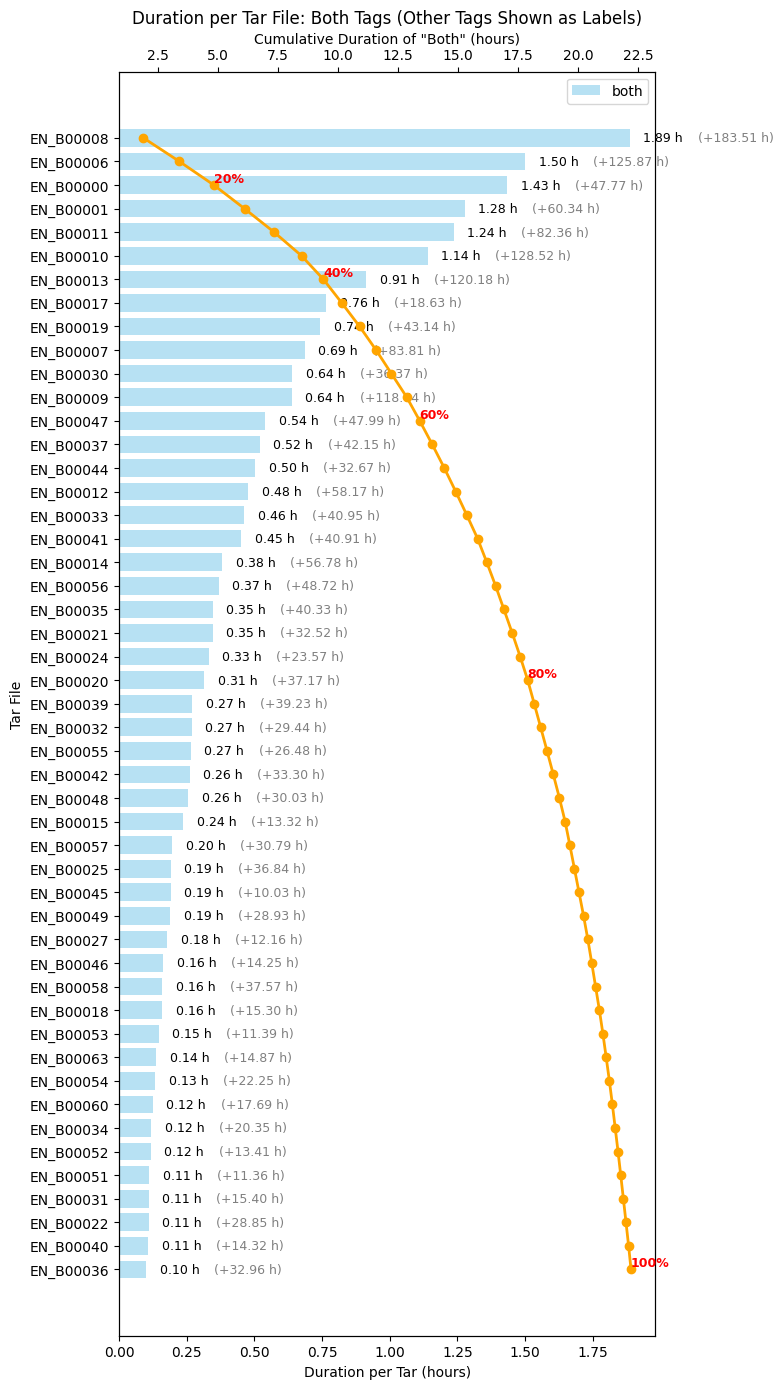

In [34]:
# find hours of speech for each tag_category grouped by source tar file
# helps to figure out which files to download
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def is_populated(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    if isinstance(x, str):
        return x != 'None' and x.strip() != ''
    if isinstance(x, (list, tuple, np.ndarray)):
        return len(x) > 0
    return True  # fallback for other types

psc_df['has_intrinsic'] = psc_df['intrinsic_tags'].apply(is_populated)
psc_df['has_situational'] = psc_df['situational_tags'].apply(is_populated)

def categorize(row):
    if row['has_intrinsic'] and row['has_situational']:
        return 'both'
    elif row['has_intrinsic']:
        return 'intrinsic_only'
    elif row['has_situational']:
        return 'situational_only'
    else:
        return 'neither'

psc_df['tag_category'] = psc_df.apply(categorize, axis=1)


emilia = psc_df[psc_df["source"] == "emilia"]

# separate out tar_file name from relative path
emilia['tar_file'] = emilia['relative_audio_path'].str.split('/').str[1]

# sum duration for each tar file by tag_category
durations = (
    emilia.groupby(['tar_file', 'tag_category'])['duration']
          .sum()
          .unstack(fill_value=0) / 3600
)

durations = durations[durations['both'] > 0.1]

# Filter out rows with all zeros
plot_df = durations[['both', 'intrinsic_only', 'situational_only']]
plot_df = plot_df[plot_df.sum(axis=1) > 0]

# Sort descending by 'both'
plot_df = plot_df.sort_values(by='both', ascending=False)

# Cumulative sum for 'both'
cumulative = plot_df['both'].cumsum()
total = cumulative.iloc[-1]
cumulative_pct = cumulative / total

fig, ax = plt.subplots(figsize=(8, 14))

# Only plot 'both' bars
y_pos = np.arange(len(plot_df))
ax.barh(y_pos, plot_df['both'], height=0.75, alpha=0.6, color='skyblue', label='both')

# Add labels: 'both' duration + other durations
for i, (b, intr, sit) in enumerate(zip(plot_df['both'], plot_df['intrinsic_only'], plot_df['situational_only'])):
    # Label for 'both'
    ax.text(b + 0.05, i, f'{b:.2f} h', va='center', ha='left', fontsize=9)
    
    # Label for sum of other durations
    other_sum = intr + sit
    if other_sum > 0:
        ax.text(b + 0.05 + 0.2, i, f'(+{other_sum:.2f} h)', va='center', ha='left', fontsize=9, color='gray')

# Reverse y-axis to have largest on top
ax.invert_yaxis()
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index)

# Cumulative line on secondary x-axis
ax2 = ax.twiny()
ax2.plot(cumulative.values, y_pos, marker='o', color='orange', linewidth=2)
ax2.set_xlabel('Cumulative Duration of "Both" (hours)')

# Add percentage labels along cumulative line
for pct in np.arange(0.2, 1.01, 0.2):
    idx = (cumulative_pct >= pct).idxmax()
    x_val = cumulative.loc[idx]
    y_val = y_pos[plot_df.index.get_loc(idx)]
    ax2.text(
        x_val,
        y_val,
        f'{int(pct*100)}%',
        color='red',
        va='bottom',
        ha='left',
        fontsize=9,
        fontweight='bold'
    )

# Labels and legend
ax.set_xlabel('Duration per Tar (hours)')
ax.set_ylabel('Tar File')
ax.set_title('Duration per Tar File: Both Tags (Other Tags Shown as Labels)')
ax.legend()

plt.tight_layout()
plt.show()

# StyleTalk

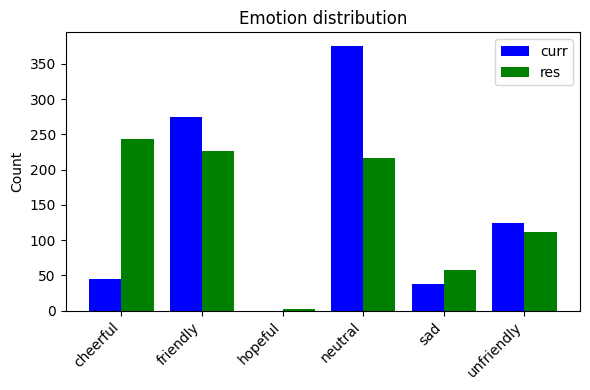

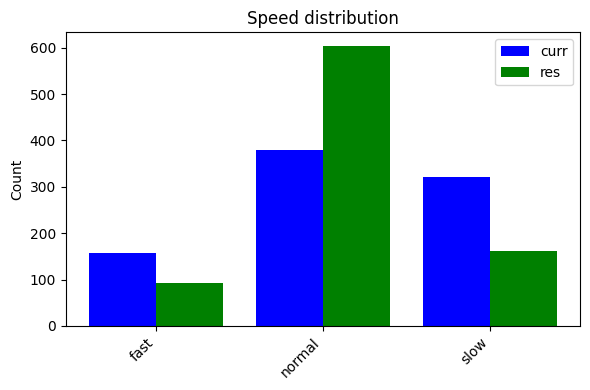

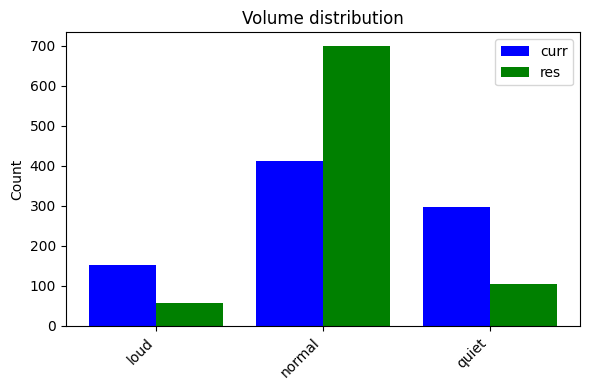

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os



def plot_curr_res_distribution(df, tag_base, figsize=(6, 4), width=0.4):
    # value counts
    curr = df[f'curr_{tag_base}'].value_counts()
    res = df[f'res_{tag_base}'].value_counts()

    # union of labels so both share the same x-axis
    labels = sorted(set(curr.index) | set(res.index))

    # reindex (missing → 0)
    curr = curr.reindex(labels, fill_value=0)
    res = res.reindex(labels, fill_value=0)

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x - width/2, curr.values, width, label='curr', color='blue')
    ax.bar(x + width/2, res.values, width, label='res', color='green')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Count')
    ax.set_title(f'{tag_base.capitalize()} distribution')
    ax.legend()

    fig.tight_layout()
    return fig, ax


os.makedirs("figures", exist_ok=True)

df = pd.read_csv(
    f"../data/raw/styletalk/annotations/eval.csv",
    sep=",",            # delimiter
    encoding="utf-8",   # or "latin1"
    na_values=["NA", ""],
)

for tag in ["emotion", "speed", "volume"]:
    fig, ax = plot_curr_res_distribution(df, tag)
    fig.savefig(f"figures/styletalk_{tag}_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

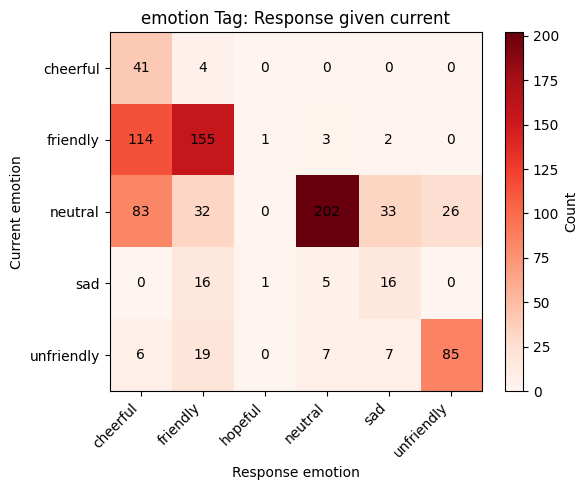

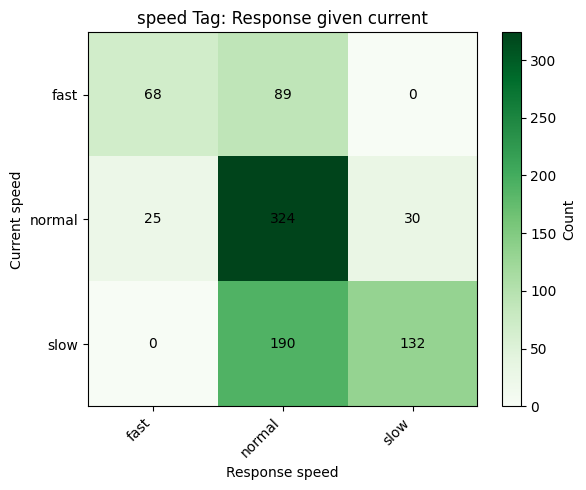

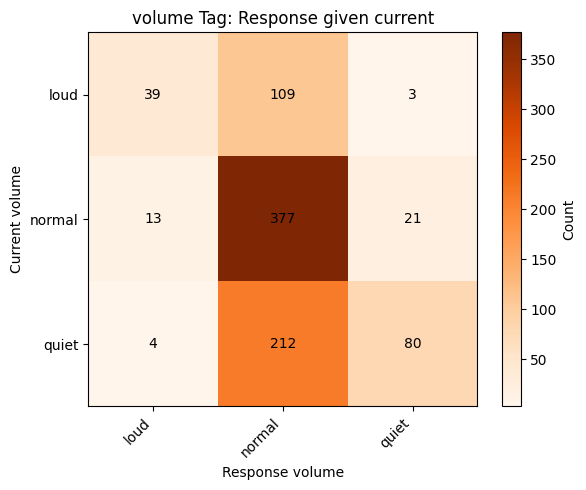

In [49]:
# Heatmap of conditional tags. p(res_emotion | curr_emotion), ...

import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
def create_cond_tag_plot(df, tag_base, colormap):
    ct = pd.crosstab(df[f"curr_{tag_base}"], df[f"res_{tag_base}"])

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(ct, aspect='auto', cmap=colormap)
    fig.colorbar(im, ax=ax, label='Count')

    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels(ct.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(ct.index)

    ax.set_xlabel('Response ' + tag_base)
    ax.set_ylabel('Current ' + tag_base)
    ax.set_title(tag_base + ' Tag: Response given current')

    # add numbers
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            value = ct.iloc[i, j]
            ax.text(j, i, value, ha='center', va='center', color='black')

    fig.tight_layout()
    return fig, ax
    

for tag, colormap in zip(['emotion','speed','volume'], ['Reds','Greens','Oranges']):
    fig, ax = create_cond_tag_plot(df, tag, colormap)
    plt.show()
    
    fig.savefig(f"figures/styletalk_{tag}_response_given_current.png", dpi=300, bbox_inches="tight")
    plt.close(fig)